# **Exercício Computacional: Support Vector Machines e Soft Margin**

## Orientações
- Use apenas `numpy` e `matplotlib`
- Complete as partes indicadas
- Interprete os gráficos obtidos
- Responda às perguntas conceituais ao final

In [33]:
# Importando bibliotecas

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

---

## Parte 1 — Geração de Dados para Classificação Binária

Considere duas classes em $\mathbb{R}^2$, rotuladas por $y \in \{-1, +1\}$.

Para este problema, pede-se:

1. Gerar duas nuvens de pontos bidimensionais
2. Construir um conjunto com \(N=100\) amostras
3. Associar rótulos \(-1\) e \(+1\)
4. Padronizar os dados
5. Plotar o dataset

In [34]:
# Gere aqui os dados de duas classes gaussianas bidimensionais

# Classe negativa
N_neg = 50
mu_neg = np.array([-2.0, -2.0])
Sigma_neg = np.array([[1.0, 0.3],
                      [0.3, 1.0]])

# Classe positiva
N_pos = 50
mu_pos = np.array([2.0, 2.0])
Sigma_pos = np.array([[1.0, -0.2],
                      [-0.2, 1.0]])

X_neg = np.random.multivariate_normal(mu_neg, Sigma_neg, size=N_neg)
X_pos = np.random.multivariate_normal(mu_pos, Sigma_pos, size=N_pos)

# Construa X e y
X = np.vstack([X_neg, X_pos])
y = np.hstack([-np.ones(N_neg), np.ones(N_pos)])

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Valores únicos de y:", np.unique(y))


Formato de X: (100, 2)
Formato de y: (100,)
Valores únicos de y: [-1.  1.]


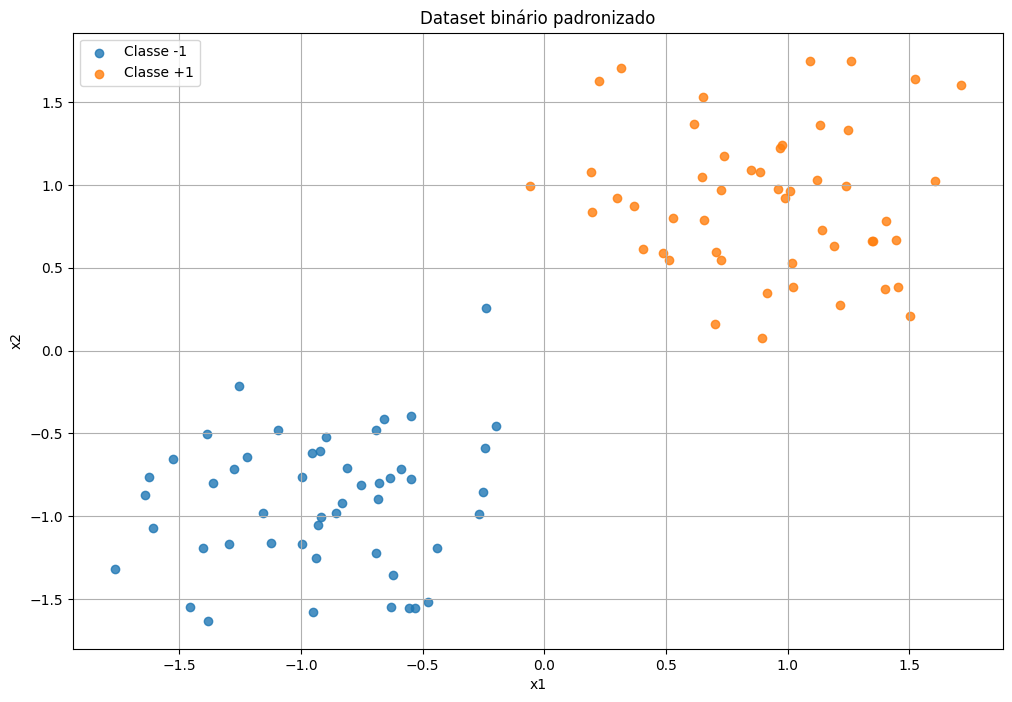

In [35]:
# Padronize os dados manualmente: média zero e variância unitária por coluna

mean_X = X.mean(axis=0)
std_X = X.std(axis=0)
X = (X - mean_X) / std_X # padronizacao

# Visualização
plt.figure(figsize=(12, 8))
plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Classe -1', alpha=0.8)
plt.scatter(X[y ==  1, 0], X[y ==  1, 1], label='Classe +1', alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset binário padronizado')
plt.legend()
plt.grid(True)
plt.show()


## Parte 2 — Função de Decisão Linear

Considere o classificador linear

$$
f(x) = w^\top x + b
$$

e a predição

$$
\hat{y} = \mathrm{sign}(f(x)).
$$

Implemente as seguintes funções auxiliares:

1. a função de decisão linear
2. a predição binária
3. a acurácia

In [36]:
# função de decisão linear
def decision_function(X, w, b):
    return X @ w + b

# função de predição
def predict_labels(X, w, b):
    scores = decision_function(X, w, b)
    return np.where(scores >= 0, 1, -1)

# função de acurácia
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


## Parte 3 — Margem Funcional e Hinge Loss

Para a SVM, a margem funcional da amostra \(n\) é dada por

$$
m_n = y_n (w^\top x_n + b).
$$

A hinge loss por amostra é

$$
\ell_n = \max(0, 1 - m_n).
$$

Implemente:

1. a margem funcional
2. a hinge loss por amostra
3. a hinge loss média

In [37]:
def functional_margin(X, y, w, b):
    return y * decision_function(X, w, b)

def hinge_losses(X, y, w, b):
    margins = functional_margin(X, y, w, b)
    return np.maximum(0, 1 - margins)

def mean_hinge_loss(X, y, w, b):
    return np.mean(hinge_losses(X, y, w, b))


In [38]:
# Teste inicial com parâmetros nulos

D = X.shape[1]
w0 = np.zeros(D)
b0 = 0.0

margins0 = functional_margin(X, y, w0, b0)
losses0 = hinge_losses(X, y, w0, b0)

print("Primeiras 5 margens:", margins0[:5])
print("Primeiras 5 losses:", losses0[:5])
print("Loss média inicial:", mean_hinge_loss(X, y, w0, b0))


Primeiras 5 margens: [-0. -0. -0. -0. -0.]
Primeiras 5 losses: [1. 1. 1. 1. 1.]
Loss média inicial: 1.0


## Parte 4 — Função Objetivo da Soft-Margin SVM

Considere a função objetivo

$$
J(w,b) = \frac{1}{2}\|w\|^2 + C \sum_{n=1}^{N}\max(0, 1 - y_n(w^\top x_n + b)).
$$

Implemente:

1. o termo de regularização
2. a função objetivo completa

In [39]:
def regularization_term(w):
    return 0.5 * np.sum(w**2)

def svm_objective(X, y, w, b, C):
    return regularization_term(w) + C * np.sum(hinge_losses(X, y, w, b))


In [40]:
C = 1.0
print("Regularização inicial:", regularization_term(w0))
print("Objetivo inicial:", svm_objective(X, y, w0, b0, C))

Regularização inicial: 0.0
Objetivo inicial: 100.0


## Parte 5 — Subgradiente da Soft-Margin SVM

Seja $\mathcal{V}$ o conjunto das amostras que violam a margem, isto é,

$$
y_n (w^\top x_n + b) < 1.
$$

Um subgradiente da função objetivo é dado por

$$
\nabla_w J = w - C \sum_{n \in \mathcal{V}} y_n x_n
$$

e

$$
\frac{\partial J}{\partial b} = -C \sum_{n \in \mathcal{V}} y_n.
$$

Implemente a função que calcula esse subgradiente.

In [41]:
def svm_subgradient(X, y, w, b, C):
    margins = functional_margin(X, y, w, b)
    violators = margins < 1 # dados que violam a margem

    grad_w = w - C * np.sum((y[violators, None] * X[violators]), axis=0)
    grad_b = -C * np.sum(y[violators])
    return grad_w, grad_b


In [42]:
grad_w0, grad_b0 = svm_subgradient(X, y, w0, b0, C=1.0)

print("grad_w inicial:", grad_w0)
print("grad_b inicial:", grad_b0)

grad_w inicial: [-91.07641128 -90.96975773]
grad_b inicial: -0.0


## Parte 6 — Treinamento da SVM por Descida de Subgradiente

Implemente o treinamento da SVM linear.

Sugestões:

1. inicialize \(w=0\) e \(b=0\)
2. atualize
   $$
   w \leftarrow w - \eta \nabla_w J
   $$
   $$
   b \leftarrow b - \eta \nabla_b J
   $$
3. armazene o histórico da função objetivo
4. use hiperparâmetros `lr`, `num_iters` e `C`

In [43]:
def fit_linear_svm_subgradient(X, y, C=1.0, lr=1e-3, num_iters=2000):
    N, D = X.shape
    w = np.zeros(D)
    b = 0.0
    history = []

    for _ in range(num_iters):
        grad_w, grad_b = svm_subgradient(X, y, w, b, C)
        w = w - lr * grad_w
        b = b - lr * grad_b
        history.append(svm_objective(X, y, w, b, C))

    return w, b, history


In [44]:
# Ajuste a SVM linear

w, b, history = fit_linear_svm_subgradient(X, y, C=1.0, lr=1e-3, num_iters=2000) 

print("w final:", w)
print("b final:", b)
print("Último valor do objetivo:", history[-1])
print("Acurácia final:", accuracy(y, predict_labels(X, w, b)))


w final: [1.16699165 1.20784214]
b final: -0.13300000000000012
Último valor do objetivo: 2.520562781354868
Acurácia final: 1.0


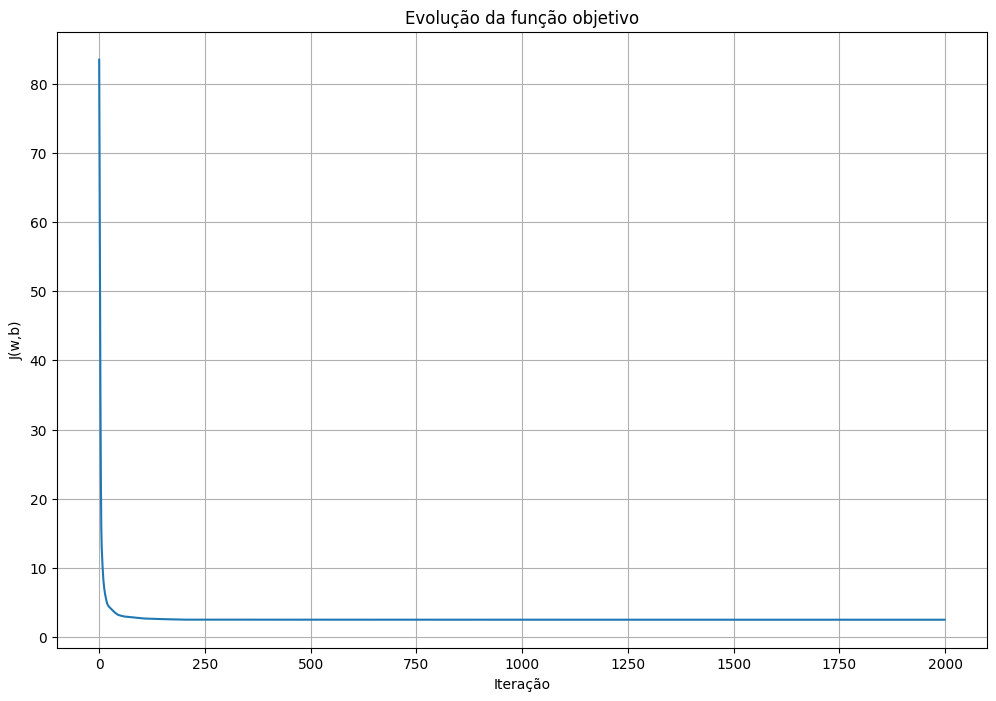

In [45]:
# Plote a evolução da função objetivo

plt.figure(figsize=(12, 8))
plt.plot(history)
plt.xlabel('Iteração')
plt.ylabel('J(w,b)')
plt.title('Evolução da função objetivo')
plt.grid(True)
plt.show()

## Parte 7 — Fronteira de Decisão e Margens

A fronteira de decisão é dada por

$$
w^\top x + b = 0
$$

As margens correspondem a

$$
w^\top x + b = +1
\qquad\text{e}\qquad
w^\top x + b = -1.
$$

Plote:

1. os dados
2. a fronteira de decisão
3. as duas margens

In [46]:
def plot_linear_svm(X, y, w, b, title='SVM linear'):
    plt.figure(figsize=(12, 8))

    # pontos
    plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Classe -1', alpha=0.8)
    plt.scatter(X[y ==  1, 0], X[y ==  1, 1], label='Classe +1', alpha=0.8)

    # reta de decisão e margens
    x1_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)

    if abs(w[1]) > 1e-12:
        decision = -(w[0] * x1_vals + b) / w[1]
        margin_pos = -(w[0] * x1_vals + b - 1) / w[1]
        margin_neg = -(w[0] * x1_vals + b + 1) / w[1]
        plt.plot(x1_vals, decision, label='Fronteira de decisão')
        plt.plot(x1_vals, margin_pos, '--', label='Margem +1')
        plt.plot(x1_vals, margin_neg, '--', label='Margem -1')
    else:
        x_decision = -b / w[0]
        x_margin_pos = (1 - b) / w[0]
        x_margin_neg = (-1 - b) / w[0]
        plt.axvline(x_decision, label='Fronteira de decisão')
        plt.axvline(x_margin_pos, linestyle='--', label='Margem +1')
        plt.axvline(x_margin_neg, linestyle='--', label='Margem -1')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


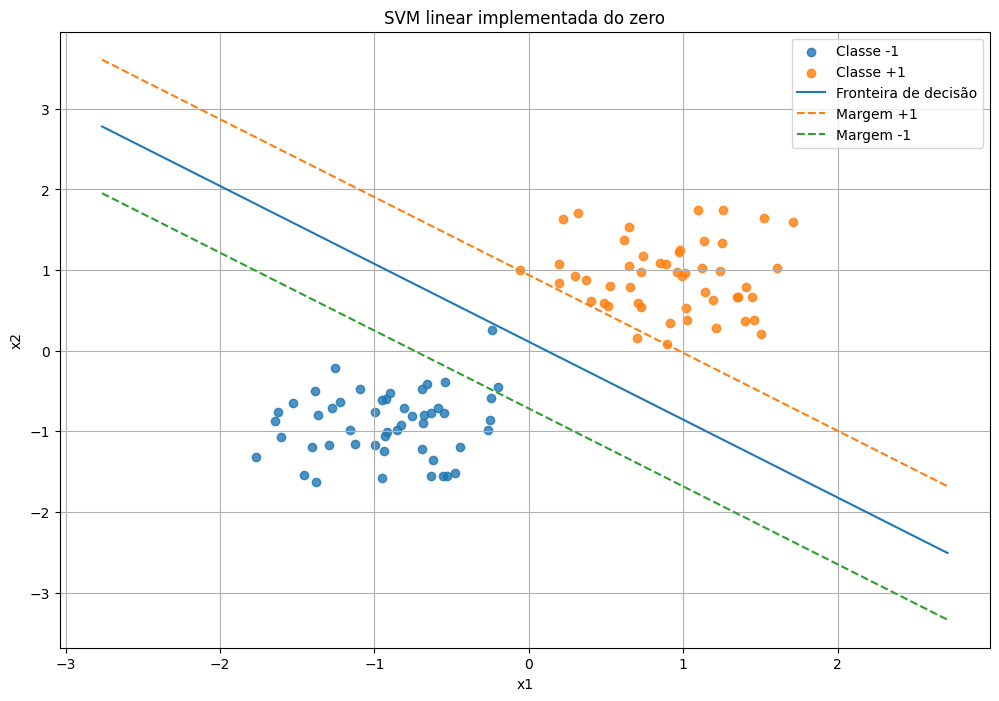

In [47]:
plot_linear_svm(X, y, w, b, title='SVM linear implementada do zero')

## Parte 8 — Support Vectors Aproximados

Na formulação geométrica, os support vectors são os pontos mais próximos das margens.

Nesta implementação numérica, podemos identificar aproximadamente pontos para os quais

$$
|y_n (w^\top x_n + b) - 1|
$$

é pequeno.

Pede-se:

1. calcular as margens funcionais
2. definir uma tolerância
3. destacar esses pontos no gráfico

Número de support vectors aproximados: 4


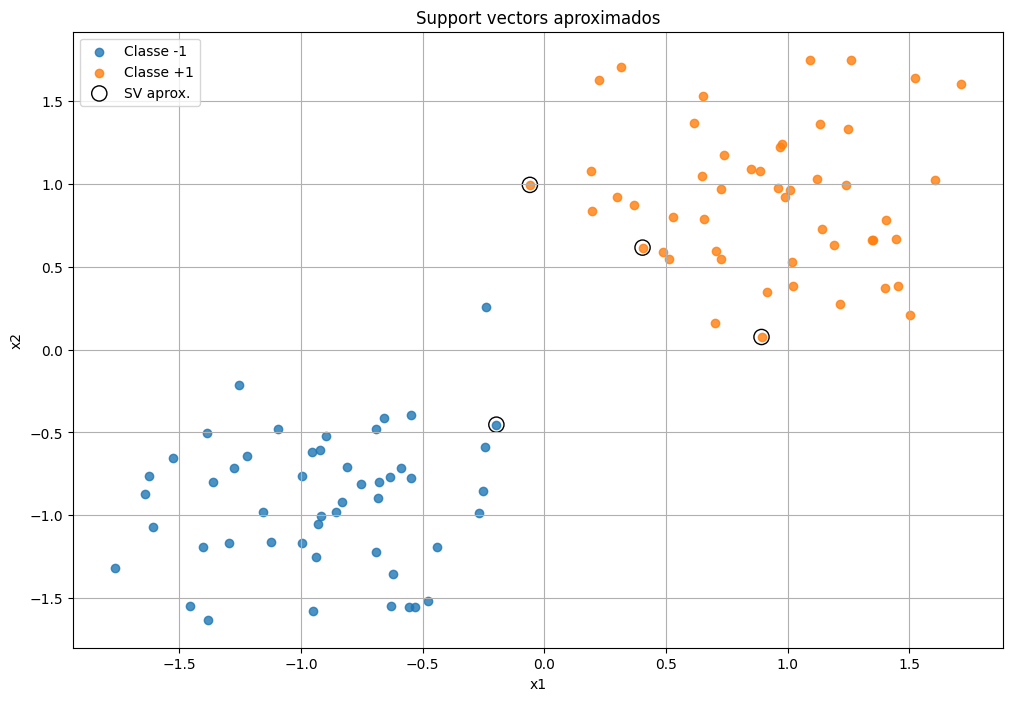

In [48]:
margins = functional_margin(X, y, w, b)
tol = 0.1
sv_mask = np.abs(margins - 1) < tol

print("Número de support vectors aproximados:", np.sum(sv_mask))

plt.figure(figsize=(12, 8))
plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Classe -1', alpha=0.8)
plt.scatter(X[y ==  1, 0], X[y ==  1, 1], label='Classe +1', alpha=0.8)
plt.scatter(X[sv_mask, 0], X[sv_mask, 1], s=120, facecolors='none', edgecolors='k', label='SV aprox.')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Support vectors aproximados')
plt.legend()
plt.grid(True)
plt.show()


## Parte 9 — Comparação com uma Implementação Pronta

Para verificar a implementação, compare sua solução com uma SVM linear ajustada por uma biblioteca padrão.

Pede-se:

1. ajustar um modelo linear de referência
2. comparar a acurácia
3. comparar a fronteira de decisão
4. comparar os parâmetros \(w\) e \(b\)

In [49]:
# Aqui usamos uma implementação pronta apenas para comparação

from sklearn.svm import SVC

clf = SVC(kernel='linear', C=1.0)
clf.fit(X, y)

y_pred_custom = predict_labels(X, w, b)
y_pred_ref = clf.predict(X)

print("Acurácia (custom):", accuracy(y, y_pred_custom))
print("Acurácia (referência):", accuracy(y, y_pred_ref))


Acurácia (custom): 1.0
Acurácia (referência): 1.0


In [50]:
w_ref = clf.coef_.ravel()
b_ref = clf.intercept_[0]

print("w (custom):", w)
print("b (custom):", b)
print("w (referência):", w_ref)
print("b (referência):", b_ref)


w (custom): [1.16699165 1.20784214]
b (custom): -0.13300000000000012
w (referência): [1.19478705 1.23831854]
b (referência): -0.16147241855536842


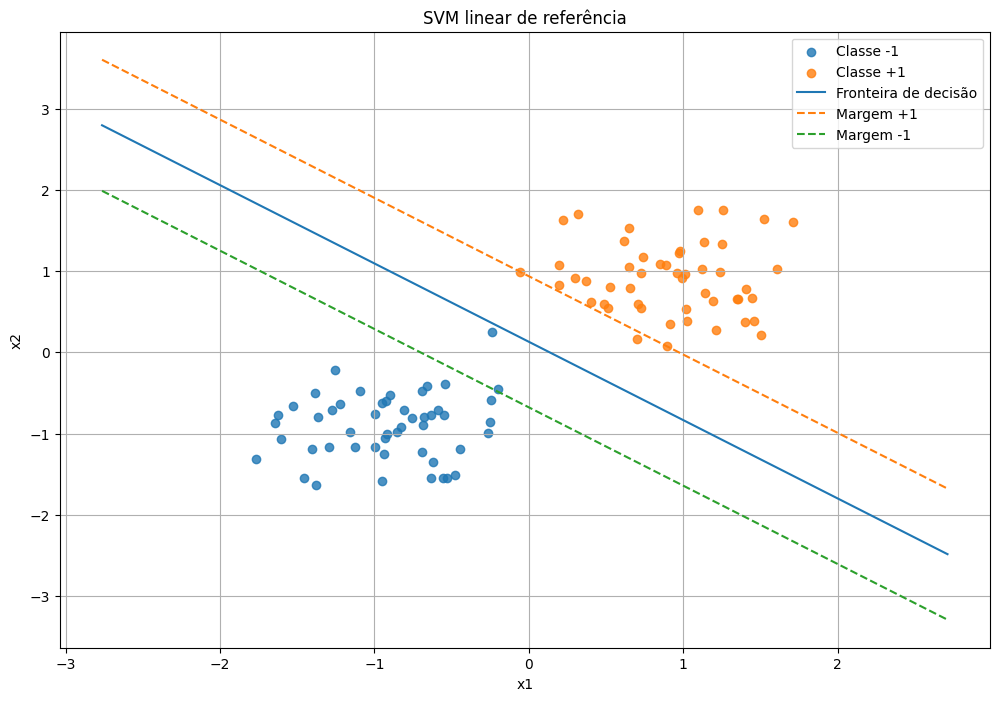

In [51]:
plot_linear_svm(X, y, w_ref, b_ref, title='SVM linear de referência')

## Parte 10 — Efeito do Parâmetro \(C\)

Considere os valores

$$
C \in \{0.01,\; 0.1,\; 1,\; 10,\; 100\}.
$$

Pede-se:

1. ajustar o modelo para diferentes valores de \(C\)
2. armazenar \(\|w\|\)
3. armazenar a acurácia
4. interpretar o efeito de \(C\)

In [52]:
C_values = [0.01, 0.1, 1, 10, 100]

norms = []
accs = []

for C in C_values:
    w_c, b_c, hist_c = fit_linear_svm_subgradient(X, y, C=C, lr=1e-3, num_iters=2000)
    y_pred_c = predict_labels(X, w_c, b_c)
    norms.append(np.linalg.norm(w_c))
    accs.append(accuracy(y, y_pred_c))

print("Normas de w:", norms)
print("Acurácias:", accs)


Normas de w: [0.6926672598252015, 1.104962590100586, 1.6795094931662857, 3.174494645745439, 3.2337390333634715]
Acurácias: [0.99, 0.99, 1.0, 1.0, 1.0]


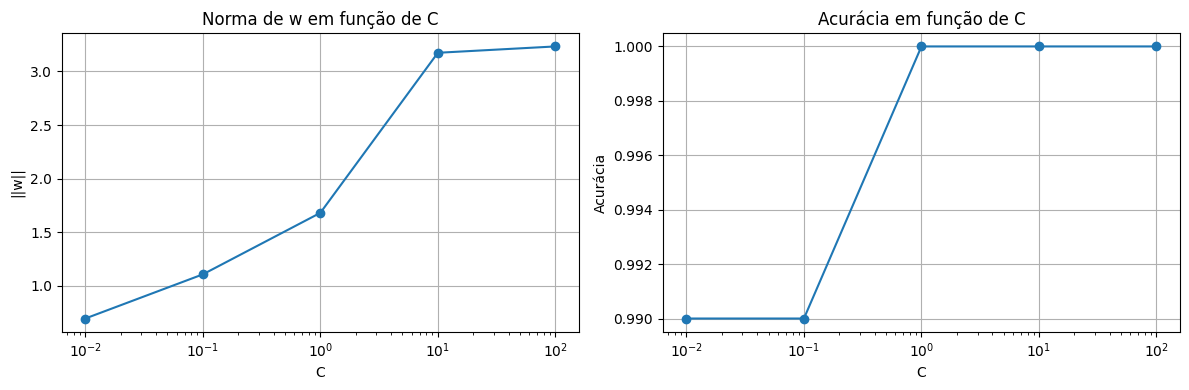

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(C_values, norms, marker='o')
axes[0].set_xscale('log')
axes[0].set_title('Norma de w em função de C')
axes[0].set_xlabel('C')
axes[0].set_ylabel('||w||')
axes[0].grid(True)

axes[1].plot(C_values, accs, marker='o')
axes[1].set_xscale('log')
axes[1].set_title('Acurácia em função de C')
axes[1].set_xlabel('C')
axes[1].set_ylabel('Acurácia')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Parte 11 — Dataset Não Linear

Agora vamos aplicar a SVM linear a um conjunto de dados que não é linearmente separável.

Pede-se:

1. gerar um dataset do tipo "luas"
2. padronizar os dados
3. ajustar a SVM linear
4. observar a fronteira obtida

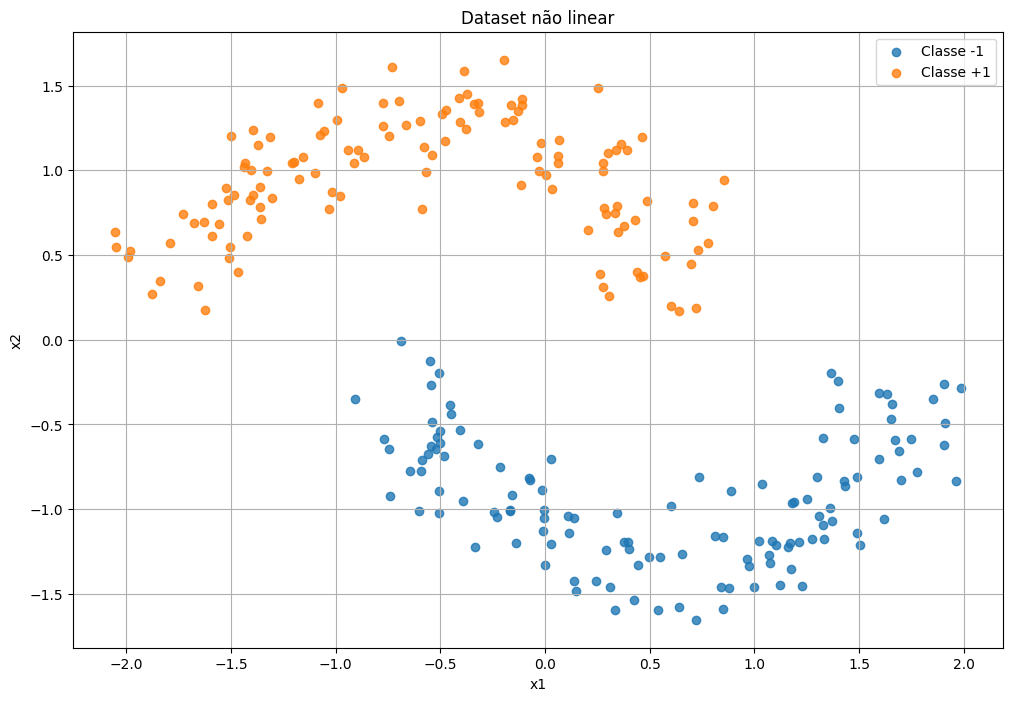

In [54]:
# Gere um dataset não linear
def make_moons_manual(n_samples=250, noise=0.15):
    n = n_samples // 2
    t1 = np.linspace(0, np.pi, n)
    t2 = np.linspace(0, np.pi, n)

    moon1 = np.c_[np.cos(t1), np.sin(t1)]
    moon2 = np.c_[1 - np.cos(t2), -np.sin(t2) - 0.5]

    X1 = moon1 + noise * np.random.randn(n, 2)
    X2 = moon2 + noise * np.random.randn(n, 2)

    X = np.vstack([X1, X2])
    y = np.hstack([np.ones(n), -np.ones(n)])
    return X, y

X_nl, y_nl = make_moons_manual()

mean_nl = X_nl.mean(axis=0)
std_nl = X_nl.std(axis=0)
X_nl = (X_nl - mean_nl) / std_nl

plt.figure(figsize=(12, 8))
plt.scatter(X_nl[y_nl == -1, 0], X_nl[y_nl == -1, 1], label='Classe -1', alpha=0.8)
plt.scatter(X_nl[y_nl ==  1, 0], X_nl[y_nl ==  1, 1], label='Classe +1', alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset não linear')
plt.legend()
plt.grid(True)
plt.show()


Acurácia da SVM linear no dataset não linear: 0.996


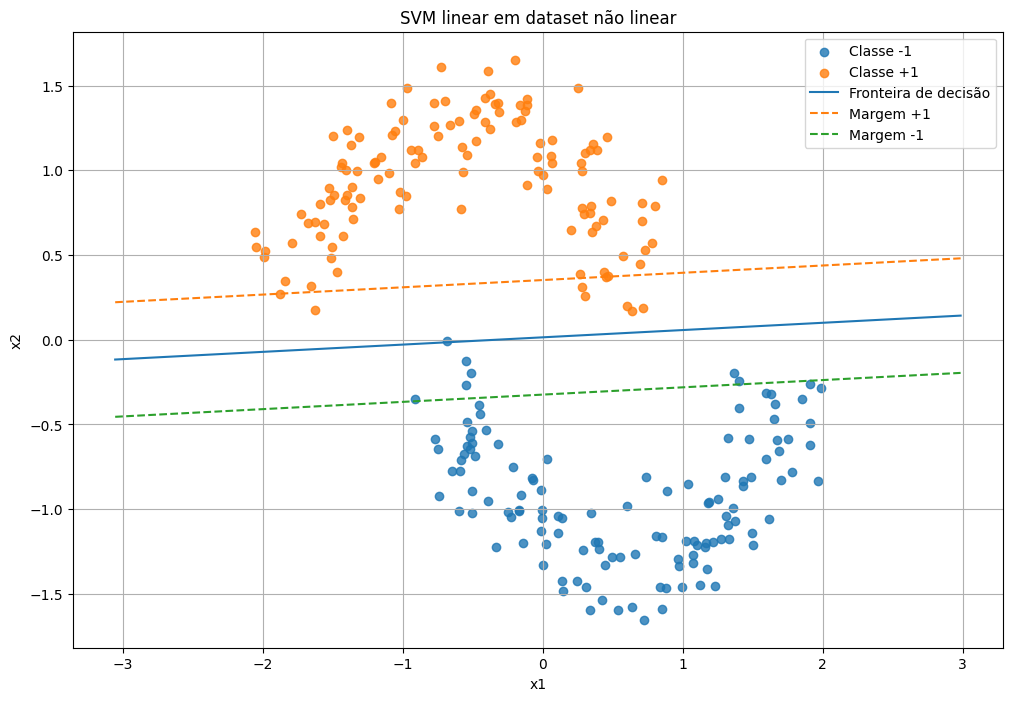

In [55]:
w_nl, b_nl, history_nl = fit_linear_svm_subgradient(X_nl, y_nl, C=1.0, lr=1e-3, num_iters=2000)

print("Acurácia da SVM linear no dataset não linear:", accuracy(y_nl, predict_labels(X_nl, w_nl, b_nl)))

plot_linear_svm(X_nl, y_nl, w_nl, b_nl, title='SVM linear em dataset não linear')


## Parte 12 — Transformação Explícita de Features

Sem usar kernels prontos, considere o mapeamento

$$
\phi(x_1,x_2) = (x_1,\; x_2,\; x_1^2,\; x_2^2,\; x_1x_2).
$$

Pede-se:

1. implementar a transformação
2. treinar novamente a SVM linear no espaço transformado
3. comparar com o caso original

In [56]:
def phi_quadratic(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.column_stack([x1, x2, x1**2, x2**2, x1 * x2])


In [57]:
X_phi = phi_quadratic(X_nl)
w_phi, b_phi, history_phi = fit_linear_svm_subgradient(X_phi, y_nl, C=1.0, lr=1e-3, num_iters=2000)

print("Formato original:", X_nl.shape)
print("Formato transformado:", X_phi.shape)
print("Acurácia após transformação quadrática:", accuracy(y_nl, predict_labels(X_phi, w_phi, b_phi)))


Formato original: (250, 2)
Formato transformado: (250, 5)
Acurácia após transformação quadrática: 1.0


In [58]:
def plot_nonlinear_boundary_from_phi(X, y, w, b, phi_func, title='Fronteira não linear'):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_phi = phi_func(grid)
    scores = grid_phi @ w + b
    Z = np.sign(scores).reshape(xx.shape)

    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, alpha=0.25, levels=[-1, 0, 1])
    plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Classe -1', alpha=0.8)
    plt.scatter(X[y ==  1, 0], X[y ==  1, 1], label='Classe +1', alpha=0.8)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

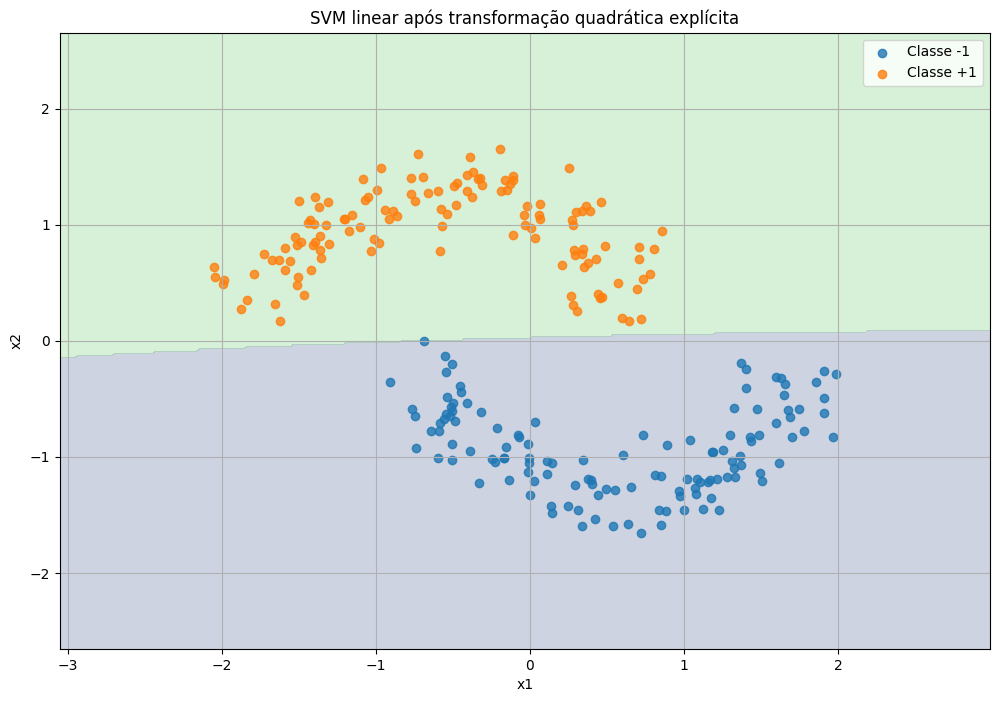

In [59]:
plot_nonlinear_boundary_from_phi(
    X_nl, y_nl, w_phi, b_phi, phi_quadratic,
    title='SVM linear após transformação quadrática explícita'
)

## Parte 13 — Questões Conceituais

Responda:

1. O que representa o vetor \(w\) na SVM?
2. Qual é o papel do termo $\frac{1}{2}\|w\|^2$?
3. O que significa violar a margem?
4. Qual é o papel do parâmetro \(C\)?
5. Por que a hinge loss é adequada para classificação?
6. Por que a SVM linear falha em dados não linearmente separáveis?
7. Como uma transformação explícita de features pode resolver esse problema?

Respostas:

1. O vetor \(w\) define a orientação da fronteira de decisão. Ele é perpendicular ao hiperplano separador e seus coeficientes determinam quanto cada feature contribui para a decisão do modelo.

2. O termo $\frac{1}{2}\|w\|^2$ atua como regularização. Ao penalizar vetores \(w\) muito grandes, ele favorece margens geométricas maiores e reduz o risco de overfitting.

3. Violar a margem significa que uma amostra satisfaz $y_n (w^\top x_n + b) < 1$. Isso inclui tanto pontos classificados corretamente, mas muito próximos da fronteira, quanto pontos mal classificados.

4. O parâmetro \(C\) controla o equilíbrio entre maximizar a margem e penalizar violações. 
- Valores grandes de \(C\) dão mais peso aos erros/violações;
- valores pequenos aceitam mais violações em troca de uma solução mais regularizada.

5. A hinge loss é adequada porque penaliza fortemente exemplos que estão do lado errado da fronteira ou dentro da margem, mas deixa de penalizar pontos já bem classificados com margem suficiente. 

6. A SVM linear falha em dados não linearmente separáveis porque tenta encontrar apenas um hiperplano no espaço original das variáveis. Quando a estrutura real de separação é curva ou mais complexa, uma reta não consegue representar bem essa divisão.

7. Uma transformação explícita de features projeta os dados para um espaço de maior dimensão, no qual classes que não eram separáveis linearmente podem passar a ser. Assim, uma SVM linear nesse novo espaço induz uma fronteira não linear no espaço original.


## Parte 14 — Conclusões

Responda de forma objetiva:

1. Qual a principal ideia geométrica da SVM?
2. Por que maximizar a margem pode melhorar a generalização?
3. Qual a diferença entre hard margin e soft margin?
4. Como o parâmetro \(C\) afeta a solução?
5. Qual a vantagem de usar transformações não lineares nas features?

Respostas:

1. A principal ideia geométrica da SVM é encontrar o hiperplano que separa as classes com a maior margem possível.

2. Maximizar a margem pode melhorar a generalização porque produz uma fronteira menos sensível a pequenas variações nos dados de treino.

3. Na hard margin, nenhuma violação é permitida; os dados precisam ser perfeitamente separáveis. Na soft margin, é permitido uma violação da margem e até erro de classificação. Essa violação é controlada pelo parâmetro \(C\).

4. O parâmetro \(C\) afeta o compromisso entre ajuste aos dados e regularização: 
- \(C\) alto força menor tolerância a violações; 
- \(C\) baixo produz uma solução mais suave e robusta.

5. A vantagem de usar transformações não lineares é permitir que relações complexas entre as classes sejam capturadas, tornando possível separar dados que não são linearmente separáveis no espaço original.
